 # Preprocesamiento + vectorización + modelos de ML

## 1 - Imports

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## 2 - Carga de datos

In [21]:
DATA_PATH = "../Data/raw/tcga_simple_train.csv"

df = pd.read_csv(DATA_PATH)

df = df.dropna(subset=["text", "t"]).copy()

df["text"] = df["text"].astype(str)
df["t"] = df["t"].astype(str).str.upper().str.strip()

df["raw_text"] = df["text"]

df.head()

,patient_id,text,t,raw_text
0,TCGA-BP-5195,Date of Recelpt: Clinical Diagnosis & History:...,T1,Date of Recelpt: Clinical Diagnosis & History:...
1,TCGA-D7-8573,"Material: 1) Material: stomach, Method of coll...",T3,"Material: 1) Material: stomach, Method of coll..."
2,TCGA-EI-7004,page 1 / 1. copy No. 3. Examination: Histopath...,T4,page 1 / 1. copy No. 3. Examination: Histopath...
3,TCGA-EB-A82B,Patient ID: Gross Description: A mass is locat...,T4,Patient ID: Gross Description: A mass is locat...
4,TCGA-A6-3808,SPECIMEN. Right colon. CLINICAL NOTES. PRE-OP ...,T3,SPECIMEN. Right colon. CLINICAL NOTES. PRE-OP ...


In [22]:
df = df.dropna(subset=["text", "t"]).copy()

df["text"] = df["text"].astype(str)
df["t"] = df["t"].astype(str).str.upper().str.strip()

df["t"].value_counts()

t
T2    1752
T3    1583
T1    1302
T4     521
Name: count, dtype: int64

## 3 - Generar textos preprocesados

In [23]:
INTERIM_DIR = Path("../Data/interim")

preprocessed_files = {
    "prep_0_base": INTERIM_DIR / "tcga_simple_train_preprocessed_0.csv",
    "prep_1_lower": INTERIM_DIR / "tcga_simple_train_preprocessed_1.csv",
    "prep_2_lemma": INTERIM_DIR / "tcga_simple_train_preprocessed_2.csv",
    "prep_3_pos": INTERIM_DIR / "tcga_simple_train_preprocessed_3.csv",
    "prep_4_lemma_pos": INTERIM_DIR / "tcga_simple_train_preprocessed_4.csv",
}

def cargar_texto_preprocesado(path):
    """
    Carga un CSV preprocesado y devuelve la columna de texto.
    La función intenta detectar automáticamente la columna correcta.
    """

    prep_df = pd.read_csv(path)

    # Posibles nombres de columna donde puede estar el texto preprocesado
    possible_text_cols = [
        "text",
        "processed_text",
        "preprocessed_text",
        "texto",
        "texto_preprocesado"
    ]

    for col in possible_text_cols:
        if col in prep_df.columns:
            return prep_df[col].fillna("").astype(str)

    # Si no encuentra ninguna columna típica, usa la primera columna de tipo texto
    object_cols = prep_df.select_dtypes(include="object").columns.tolist()

    if len(object_cols) > 0:
        return prep_df[object_cols[0]].fillna("").astype(str)

    raise ValueError(f"No se ha encontrado columna de texto en {path}. Columnas: {prep_df.columns.tolist()}")


for col_name, file_path in preprocessed_files.items():
    print(f"Cargando {col_name} desde {file_path}")

    if not file_path.exists():
        raise FileNotFoundError(f"No existe el archivo: {file_path}")

    processed_text = cargar_texto_preprocesado(file_path)

    if len(processed_text) != len(df):
        raise ValueError(
            f"El archivo {file_path} tiene {len(processed_text)} filas, "
            f"pero el dataset original tiene {len(df)} filas."
        )

    df[col_name] = processed_text.values

df.head()

Cargando prep_0_base desde ..\Data\interim\tcga_simple_train_preprocessed_0.csv
Cargando prep_1_lower desde ..\Data\interim\tcga_simple_train_preprocessed_1.csv
Cargando prep_2_lemma desde ..\Data\interim\tcga_simple_train_preprocessed_2.csv
Cargando prep_3_pos desde ..\Data\interim\tcga_simple_train_preprocessed_3.csv
Cargando prep_4_lemma_pos desde ..\Data\interim\tcga_simple_train_preprocessed_4.csv


,patient_id,text,t,raw_text,prep_0_base,prep_1_lower,prep_2_lemma,prep_3_pos,prep_4_lemma_pos
0,TCGA-BP-5195,Date of Recelpt: Clinical Diagnosis & History:...,T1,Date of Recelpt: Clinical Diagnosis & History:...,Date Recelpt Clinical Diagnosis History Incide...,date recelpt clinical diagnosis history incide...,date recelpt clinical diagnosis history incide...,date recelpt clinical diagnosis history incide...,date recelpt clinical diagnosis history incide...
1,TCGA-D7-8573,"Material: 1) Material: stomach, Method of coll...",T3,"Material: 1) Material: stomach, Method of coll...",Material 1 Material stomach Method collection ...,material 1 material stomach method collection ...,material 1 material stomach method collection ...,material material stomach method collection le...,material material stomach method collection le...
2,TCGA-EI-7004,page 1 / 1. copy No. 3. Examination: Histopath...,T4,page 1 / 1. copy No. 3. Examination: Histopath...,page 1 1 copy 3 Examination Histopathological ...,page 1 1 copy 3 examination histopathological ...,page 1 1 copy 3 examination histopathological ...,page copy examination histopathological examin...,page copy examination histopathological examin...
3,TCGA-EB-A82B,Patient ID: Gross Description: A mass is locat...,T4,Patient ID: Gross Description: A mass is locat...,Patient ID Gross Description mass located righ...,patient id gross description mass located righ...,patient id gross description mass locate right...,patient id gross description mass located righ...,patient id gross description mass locate right...
4,TCGA-A6-3808,SPECIMEN. Right colon. CLINICAL NOTES. PRE-OP ...,T3,SPECIMEN. Right colon. CLINICAL NOTES. PRE-OP ...,SPECIMEN Right colon CLINICAL NOTES PRE OP DIA...,specimen right colon clinical notes pre op dia...,specimen right colon clinical note pre op diag...,specimen right colon clinical notes pre op dia...,specimen right colon clinical note pre op diag...


## 4 - Train / Validation

In [24]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["t"]
)

print(train_df.shape)
print(val_df.shape)

(4126, 9)
(1032, 9)


In [25]:
y_train = train_df["t"]
y_val = val_df["t"]

## 5 - Definimos los textos a probar

In [26]:
text_columns = [
    "raw_text",
    "prep_1_lower",
    "prep_2_lemma",
    "prep_3_pos",
    "prep_4_lemma_pos"
]

## 6 - Vectorizaciones

In [27]:
vectorizers = {
    "bow_binary": CountVectorizer(
        binary=True,
        ngram_range=(1, 2),
        min_df=2
    ),

    "bow_counts": CountVectorizer(
        binary=False,
        ngram_range=(1, 2),
        min_df=2
    ),

    "tfidf_word": TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True
    ),

    "tfidf_char": TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=2,
        sublinear_tf=True
    )
}

## 7 - Cargamos los modelos de ML clásicos

In [28]:
models = {
    "multinomial_nb": MultinomialNB(),

    "complement_nb": ComplementNB(),

    "logistic_regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),

    "linear_svm": LinearSVC(
        class_weight="balanced",
        random_state=42
    )
}

## 8 - Ejecutamos nuestros diferentes modelos de Machine Learning

In [29]:
results = []

best_f1 = 0
best_model = None
best_config = None

for text_col in text_columns:

    X_train = train_df[text_col].fillna("").astype(str)
    X_val = val_df[text_col].fillna("").astype(str)

    for vec_name, vectorizer in vectorizers.items():

        for model_name, model in models.items():

            experiment_name = f"{text_col} + {vec_name} + {model_name}"
            print("Ejecutando:", experiment_name)

            pipeline = Pipeline([
                ("vectorizer", vectorizer),
                ("model", model)
            ])

            pipeline.fit(X_train, y_train)

            y_pred = pipeline.predict(X_val)

            macro_f1 = f1_score(y_val, y_pred, average="macro")
            weighted_f1 = f1_score(y_val, y_pred, average="weighted")

            results.append({
                "experiment": experiment_name,
                "text_column": text_col,
                "vectorizer": vec_name,
                "model": model_name,
                "macro_f1": macro_f1,
                "weighted_f1": weighted_f1
            })

            print("Macro F1:", round(macro_f1, 4))

            if macro_f1 > best_f1:
                best_f1 = macro_f1
                best_model = pipeline
                best_config = {
                    "text_column": text_col,
                    "vectorizer": vec_name,
                    "model": model_name,
                    "macro_f1": macro_f1
                }

Ejecutando: raw_text + bow_binary + multinomial_nb
Macro F1: 0.5402
Ejecutando: raw_text + bow_binary + complement_nb
Macro F1: 0.5327
Ejecutando: raw_text + bow_binary + logistic_regression
Macro F1: 0.7163
Ejecutando: raw_text + bow_binary + linear_svm


C:\Users\hugo\PycharmProjects\OncoNLP\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Macro F1: 0.679
Ejecutando: raw_text + bow_counts + multinomial_nb
Macro F1: 0.5237
Ejecutando: raw_text + bow_counts + complement_nb
Macro F1: 0.5271
Ejecutando: raw_text + bow_counts + logistic_regression
Macro F1: 0.6685
Ejecutando: raw_text + bow_counts + linear_svm


C:\Users\hugo\PycharmProjects\OncoNLP\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Macro F1: 0.613
Ejecutando: raw_text + tfidf_word + multinomial_nb
Macro F1: 0.4299
Ejecutando: raw_text + tfidf_word + complement_nb
Macro F1: 0.521
Ejecutando: raw_text + tfidf_word + logistic_regression
Macro F1: 0.6124
Ejecutando: raw_text + tfidf_word + linear_svm
Macro F1: 0.6883
Ejecutando: raw_text + tfidf_char + multinomial_nb
Macro F1: 0.3798
Ejecutando: raw_text + tfidf_char + complement_nb
Macro F1: 0.4515
Ejecutando: raw_text + tfidf_char + logistic_regression
Macro F1: 0.641
Ejecutando: raw_text + tfidf_char + linear_svm
Macro F1: 0.7155
Ejecutando: prep_1_lower + bow_binary + multinomial_nb
Macro F1: 0.5458
Ejecutando: prep_1_lower + bow_binary + complement_nb
Macro F1: 0.5474
Ejecutando: prep_1_lower + bow_binary + logistic_regression
Macro F1: 0.7165
Ejecutando: prep_1_lower + bow_binary + linear_svm


...

Macro F1: 0.6362
Ejecutando: prep_3_pos + tfidf_word + multinomial_nb
Macro F1: 0.4428
Ejecutando: prep_3_pos + tfidf_word + complement_nb
Macro F1: 0.5323
Ejecutando: prep_3_pos + tfidf_word + logistic_regression
Macro F1: 0.6239
Ejecutando: prep_3_pos + tfidf_word + linear_svm
Macro F1: 0.7011
Ejecutando: prep_3_pos + tfidf_char + multinomial_nb
Macro F1: 0.4028
Ejecutando: prep_3_pos + tfidf_char + complement_nb
Macro F1: 0.4886
Ejecutando: prep_3_pos + tfidf_char + logistic_regression
Macro F1: 0.6483
Ejecutando: prep_3_pos + tfidf_char + linear_svm
Macro F1: 0.7385
Ejecutando: prep_4_lemma_pos + bow_binary + multinomial_nb
Macro F1: 0.546
Ejecutando: prep_4_lemma_pos + bow_binary + complement_nb
Macro F1: 0.5438
Ejecutando: prep_4_lemma_pos + bow_binary + logistic_regression
Macro F1: 0.7181
Ejecutando: prep_4_lemma_pos + bow_binary + linear_svm


C:\Users\hugo\PycharmProjects\OncoNLP\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Macro F1: 0.6805
Ejecutando: prep_4_lemma_pos + bow_counts + multinomial_nb
Macro F1: 0.5334
Ejecutando: prep_4_lemma_pos + bow_counts + complement_nb
Macro F1: 0.5326
Ejecutando: prep_4_lemma_pos + bow_counts + logistic_regression
Macro F1: 0.6777
Ejecutando: prep_4_lemma_pos + bow_counts + linear_svm


C:\Users\hugo\PycharmProjects\OncoNLP\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Macro F1: 0.6392
Ejecutando: prep_4_lemma_pos + tfidf_word + multinomial_nb
Macro F1: 0.448
Ejecutando: prep_4_lemma_pos + tfidf_word + complement_nb
Macro F1: 0.5316
Ejecutando: prep_4_lemma_pos + tfidf_word + logistic_regression
Macro F1: 0.6223
Ejecutando: prep_4_lemma_pos + tfidf_word + linear_svm
Macro F1: 0.699
Ejecutando: prep_4_lemma_pos + tfidf_char + multinomial_nb
Macro F1: 0.4016
Ejecutando: prep_4_lemma_pos + tfidf_char + complement_nb
Macro F1: 0.4922
Ejecutando: prep_4_lemma_pos + tfidf_char + logistic_regression
Macro F1: 0.6621
Ejecutando: prep_4_lemma_pos + tfidf_char + linear_svm
Macro F1: 0.7447


## 9 - Resultados

In [30]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="macro_f1", ascending=False)

results_df.head(20)

,experiment,text_column,vectorizer,model,macro_f1,weighted_f1
47,prep_2_lemma + tfidf_char + linear_svm,prep_2_lemma,tfidf_char,linear_svm,0.747467,0.758444
79,prep_4_lemma_pos + tfidf_char + linear_svm,prep_4_lemma_pos,tfidf_char,linear_svm,0.744699,0.754795
63,prep_3_pos + tfidf_char + linear_svm,prep_3_pos,tfidf_char,linear_svm,0.738498,0.750709
31,prep_1_lower + tfidf_char + linear_svm,prep_1_lower,tfidf_char,linear_svm,0.735094,0.751484
66,prep_4_lemma_pos + bow_binary + logistic_regre...,prep_4_lemma_pos,bow_binary,logistic_regression,0.718072,0.737126
18,prep_1_lower + bow_binary + logistic_regression,prep_1_lower,bow_binary,logistic_regression,0.716470,0.734265
2,raw_text + bow_binary + logistic_regression,raw_text,bow_binary,logistic_regression,0.716313,0.732745
15,raw_text + tfidf_char + linear_svm,raw_text,tfidf_char,linear_svm,0.715458,0.730953
34,prep_2_lemma + bow_binary + logistic_regression,prep_2_lemma,bow_binary,logistic_regression,0.711596,0.730025
50,prep_3_pos + bow_binary + logistic_regression,prep_3_pos,bow_binary,logistic_regression,0.706415,0.726440


In [31]:
results_df.to_csv("../Results/resultados_ml_clasicos.csv", index=False)

## 10 - Hacemos el gráfico con los mejores resultados según *F1-score*

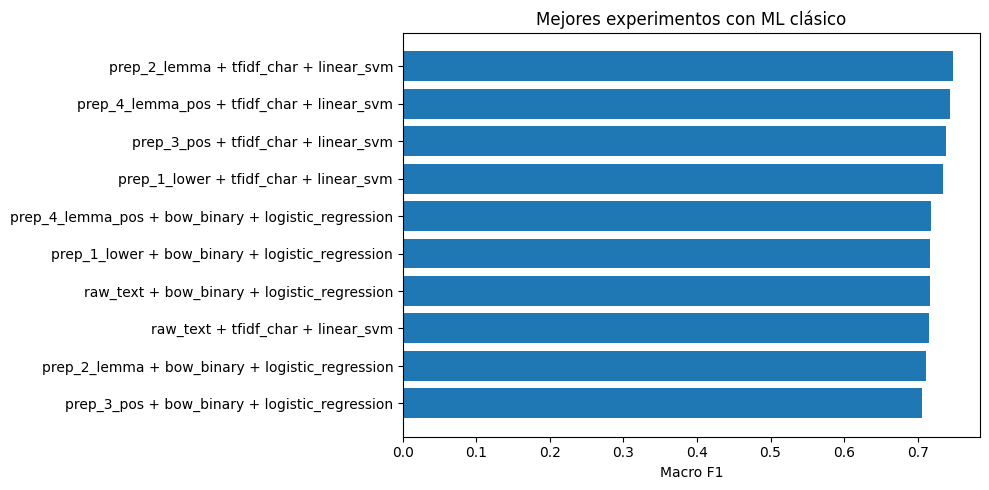

In [32]:
top = results_df.head(10)

plt.figure(figsize=(10, 5))
plt.barh(top["experiment"], top["macro_f1"])
plt.xlabel("Macro F1")
plt.title("Mejores experimentos con ML clásico")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 11 - Evaluación del mejor modelo

In [33]:
best_config

{'text_column': 'prep_2_lemma',
 'vectorizer': 'tfidf_char',
 'model': 'linear_svm',
 'macro_f1': 0.7474672795800328}

In [34]:
best_text_col = best_config["text_column"]

X_val_best = val_df[best_text_col].fillna("").astype(str)

y_pred_best = best_model.predict(X_val_best)

print(classification_report(y_val, y_pred_best))

              precision    recall  f1-score   support

          T1       0.76      0.79      0.77       260
          T2       0.77      0.77      0.77       351
          T3       0.78      0.77      0.77       317
          T4       0.72      0.65      0.69       104

    accuracy                           0.76      1032
   macro avg       0.76      0.75      0.75      1032
weighted avg       0.76      0.76      0.76      1032



## 12 - Matriz de confusion del mejor modelo

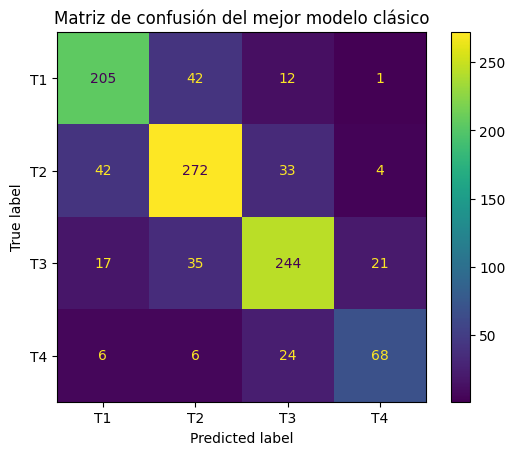

In [35]:
labels = sorted(df["t"].unique())

cm = confusion_matrix(y_val, y_pred_best, labels=labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot()
plt.title("Matriz de confusión del mejor modelo clásico")
plt.show()